# INF265 Project 2 - Object Detection Pipeline

This notebook implements Section 3 end-to-end: data analysis, grid-label conversion (3.1.1), fully convolutional detection models (3.1.2), automatic model selection, and final test evaluation.

## 3.0 Setup and Reproducibility

Import dependencies, define configuration and hyperparameters, set random seeds, and select device for reproducible experiments.

In [ ]:
# Imports, Config, Seeds, Device.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import time
import copy
from pathlib import Path
import pandas as pd

# Reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True   # reproducible but slightly slower
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

#  Configuration dictionary.
CONFIG = {
    "seed": SEED,
    "Hin": 48,
    "Win": 60,
    "Hout": 2,                  # grid rows
    "Wout": 3,                  # grid cols
    "C": 2,                     # number of classes (digits 0 and 1)
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 30,
    "pc_threshold": 0.5,
    "lambda_obj": 1.0,
    "lambda_bbox": 5.0,
    "lambda_cls": 1.0,
    "grad_clip": 5.0,
    "early_stop_patience": 5,   # stop if val_loss does not improve for this many epochs
    "augment": True,            # label-preserving augmentation in training loop
}

for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Device: cuda
  seed: 42
  Hin: 48
  Win: 60
  Hout: 2
  Wout: 3
  C: 2
  batch_size: 64
  lr: 0.001
  weight_decay: 0.0001
  epochs: 30
  pc_threshold: 0.5
  lambda_obj: 1.0
  lambda_bbox: 5.0
  lambda_cls: 1.0
  grad_clip: 5.0
  early_stop_patience: 5
  augment: True


In [ ]:
# Load the data.
H_in, W_in = 48, 60
CONFIG["Hin"] = H_in
CONFIG["Win"] = W_in

# Load detection datasets (TensorDatasets with images + pre-made 2x3 grid labels).

ds_train = torch.load("detection_train.pt", weights_only=False)
ds_val   = torch.load("detection_val.pt",   weights_only=False)
ds_test  = torch.load("detection_test.pt",  weights_only=False)

X_train_raw, y_train_grid_provided = ds_train.tensors
X_val_raw,   y_val_grid_provided   = ds_val.tensors
X_test_raw,  y_test_grid_provided  = ds_test.tensors

# Load list-format labels.
list_y_true_train = torch.load("list_y_true_train.pt", weights_only=False)
list_y_true_val   = torch.load("list_y_true_val.pt",   weights_only=False)
list_y_true_test  = torch.load("list_y_true_test.pt",  weights_only=False)

print(f"Train images: {X_train_raw.shape}  labels (grid): {y_train_grid_provided.shape}  list labels: {len(list_y_true_train)}")
print(f"Val   images: {X_val_raw.shape}  labels (grid): {y_val_grid_provided.shape}  list labels: {len(list_y_true_val)}")
print(f"Test  images: {X_test_raw.shape}  labels (grid): {y_test_grid_provided.shape}  list labels: {len(list_y_true_test)}")

# Basic checks.
for name, X in [("Train", X_train_raw), ("Val", X_val_raw), ("Test", X_test_raw)]:
    print(f"\n{name} images — min: {X.min():.4f}, max: {X.max():.4f}, mean: {X.mean():.4f}, std: {X.std():.4f}")
    print(f"  NaN: {torch.isnan(X).any().item()}, Inf: {torch.isinf(X).any().item()}")

Train images: torch.Size([26874, 1, 48, 60])  labels (grid): torch.Size([26874, 2, 3, 6])  list labels: 26874
Val   images: torch.Size([2967, 1, 48, 60])  labels (grid): torch.Size([2967, 2, 3, 6])  list labels: 2967
Test  images: torch.Size([4981, 1, 48, 60])  labels (grid): torch.Size([4981, 2, 3, 6])  list labels: 4981

Train images — min: 0.0000, max: 1.4157, mean: 0.2989, std: 0.1967
  NaN: False, Inf: False

Val images — min: 0.0000, max: 1.0000, mean: 0.2980, std: 0.1959
  NaN: False, Inf: False

Test images — min: 0.0000, max: 1.0000, mean: 0.2992, std: 0.1966
  NaN: False, Inf: False


### Pixel value distribution analysis

Pixel value statistics (raw, pre-normalization):
Split         Min      Max     Mean      Std   Median       p1      p99
--------------------------------------------------------------------
Train      0.0000   1.4157   0.2989   0.1967   0.2794   0.0000   0.9922
Val        0.0000   1.0000   0.2980   0.1959   0.2789   0.0000   0.9922
Test       0.0000   1.0000   0.2992   0.1966   0.2797   0.0000   0.9922


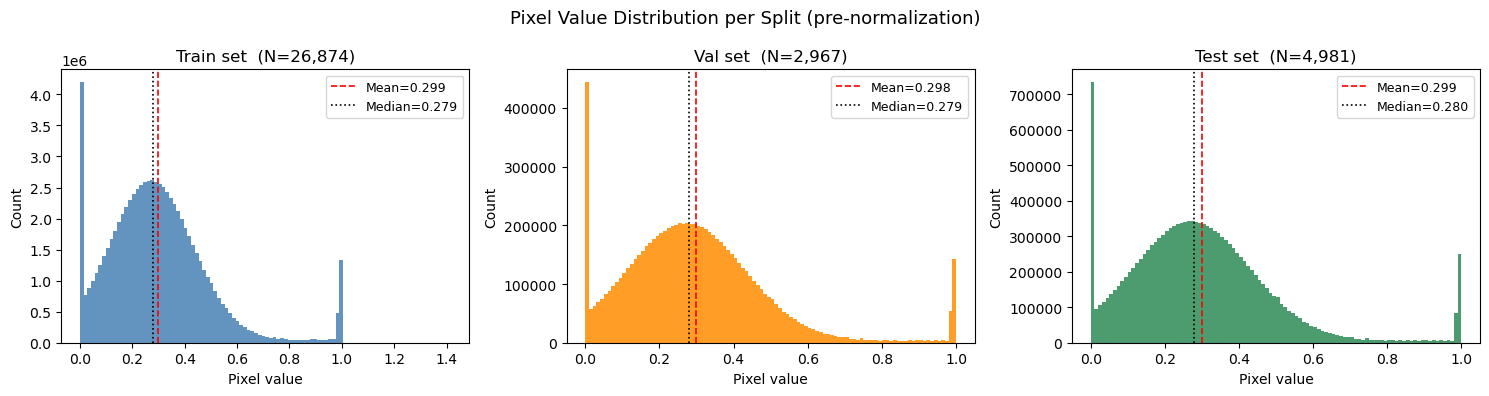

In [ ]:
splits = [('Train', X_train_raw), ('Val', X_val_raw), ('Test', X_test_raw)]

print('Pixel value statistics (raw, pre-normalization):')
print(f'{"Split":<8} {"Min":>8} {"Max":>8} {"Mean":>8} {"Std":>8} {"Median":>8} {"p1":>8} {"p99":>8}')
print('-' * 68)
for name, X in splits:
    flat = X.flatten()
    p1  = flat.kthvalue(max(1, int(0.01 * len(flat)))).values.item()
    p99 = flat.kthvalue(min(len(flat), int(0.99 * len(flat)))).values.item()
    print(f'{name:<8} {X.min().item():>8.4f} {X.max().item():>8.4f} '
          f'{X.mean().item():>8.4f} {X.std().item():>8.4f} '
          f'{flat.median().item():>8.4f} {p1:>8.4f} {p99:>8.4f}')

# Pixel distribution analysis visualisation.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Pixel Value Distribution per Split (pre-normalization)', fontsize=13)

colors = ['steelblue', 'darkorange', 'seagreen']
for ax, (name, X), color in zip(axes, splits, colors):
    flat = X.flatten().numpy()
    ax.hist(flat, bins=100, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(flat.mean(), color='red',   linestyle='--', linewidth=1.2, label=f'Mean={flat.mean():.3f}')
    ax.axvline(float(np.median(flat)), color='black', linestyle=':',  linewidth=1.2, label=f'Median={float(np.median(flat)):.3f}')
    ax.set_title(f'{name} set  (N={len(X):,})')
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Data analysis shows that the datasest is near balanced

In [ ]:
# Data analysis: object counts, class balance, bbox statistics.
def analyze_list_labels(list_y, name=""):
    """Analyze list-format labels for a split."""
    n_objects = [len(objs) for objs in list_y]
    all_classes = []
    all_w, all_h = [], []
    for objs in list_y:
        for obj in objs:
            all_classes.append(int(obj[5].item()))
            all_w.append(obj[3].item())
            all_h.append(obj[4].item())
    print(f"\n--- {name} ({len(list_y)} images) ---")
    print(f"  Objects per image: min={min(n_objects)}, max={max(n_objects)}, mean={np.mean(n_objects):.2f}")
    print(f"  Total objects: {sum(n_objects)}")
    unique, counts = np.unique(all_classes, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} ({100*c/len(all_classes):.1f}%)")
    print(f"  BBox width  — min: {min(all_w):.4f}, max: {max(all_w):.4f}, mean: {np.mean(all_w):.4f}")
    print(f"  BBox height — min: {min(all_h):.4f}, max: {max(all_h):.4f}, mean: {np.mean(all_h):.4f}")
    return n_objects, all_classes, all_w, all_h

n_obj_train, cls_train, w_train, h_train = analyze_list_labels(list_y_true_train, "Train")
n_obj_val,   cls_val,   w_val,   h_val   = analyze_list_labels(list_y_true_val,   "Val")
n_obj_test,  cls_test,  w_test,  h_test  = analyze_list_labels(list_y_true_test,  "Test")


--- Train (26874 images) ---
  Objects per image: min=1, max=4, mean=1.27
  Total objects: 34260
  Class 0: 16035 (46.8%)
  Class 1: 18225 (53.2%)
  BBox width  — min: 0.0167, max: 0.5167, mean: 0.2164
  BBox height — min: 0.1250, max: 0.6250, mean: 0.3723

--- Val (2967 images) ---
  Objects per image: min=1, max=3, mean=1.26
  Total objects: 3735
  Class 0: 1734 (46.4%)
  Class 1: 2001 (53.6%)
  BBox width  — min: 0.0333, max: 0.4833, mean: 0.2134
  BBox height — min: 0.1458, max: 0.6042, mean: 0.3711

--- Test (4981 images) ---
  Objects per image: min=1, max=4, mean=1.27
  Total objects: 6345
  Class 0: 2940 (46.3%)
  Class 1: 3405 (53.7%)
  BBox width  — min: 0.0167, max: 0.4833, mean: 0.2127
  BBox height — min: 0.1458, max: 0.6250, mean: 0.3724


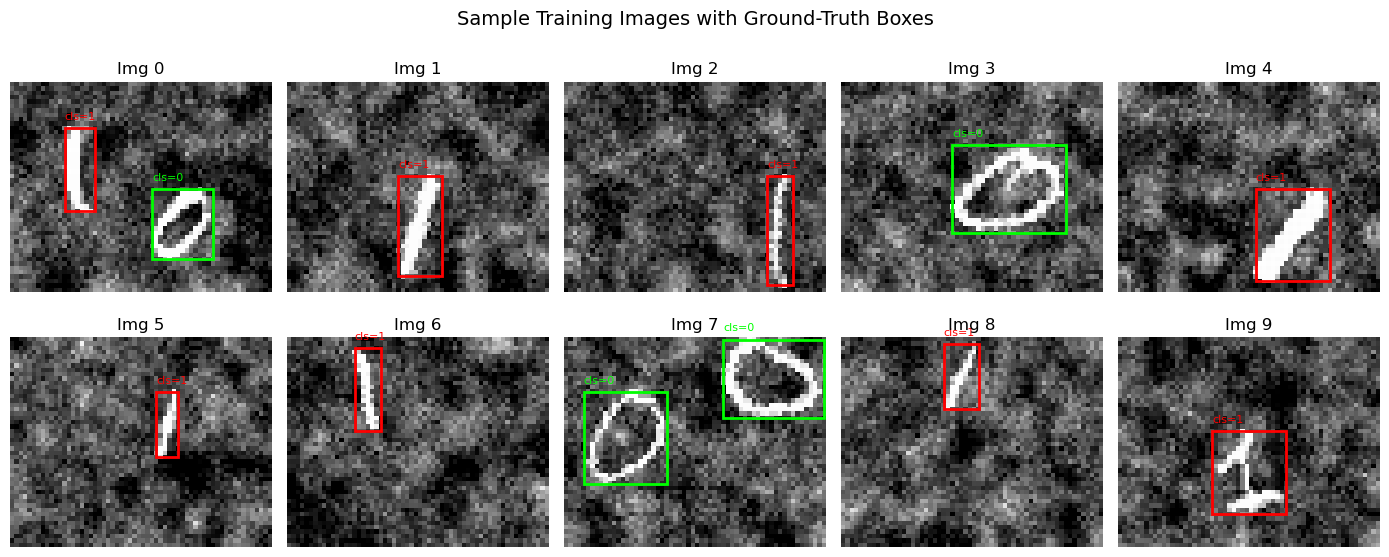

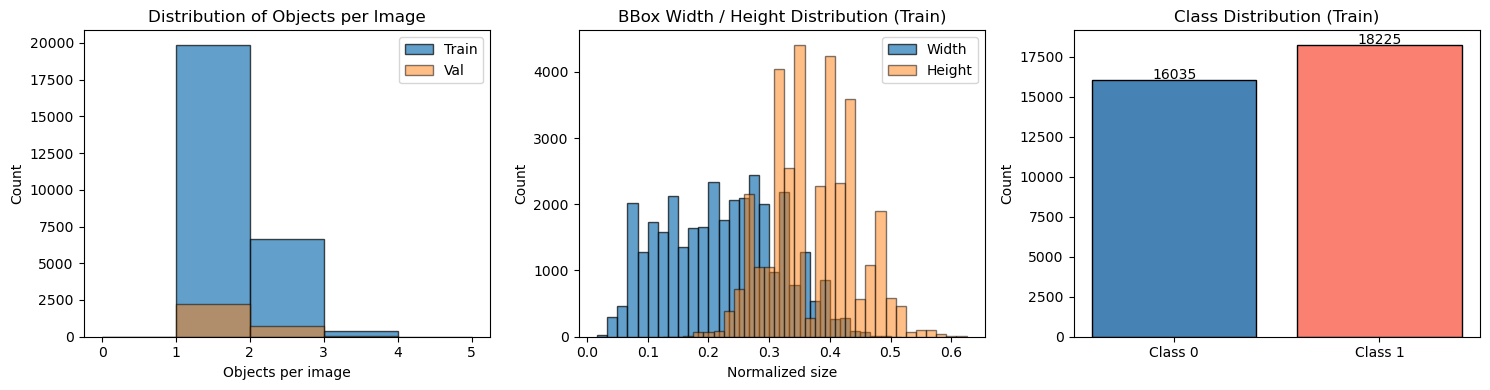

In [ ]:
# Visualizations: sample images, histograms, class distribution.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Training Images with Ground‐Truth Boxes", fontsize=14)
for idx, ax in enumerate(axes.flat):
    img = X_train_raw[idx, 0].numpy()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    for obj in list_y_true_train[idx]:
        pc, xc, yc, w, h, c = obj.tolist()
        if pc == 1:
            x1 = (xc - w / 2) * CONFIG["Win"]
            y1 = (yc - h / 2) * CONFIG["Hin"]
            rect = patches.Rectangle((x1, y1), w * CONFIG["Win"], h * CONFIG["Hin"],
                                     linewidth=2, edgecolor="lime" if c == 0 else "red",
                                     facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, f"cls={int(c)}", color="lime" if c == 0 else "red", fontsize=8)
    ax.set_title(f"Img {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Histograms.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(n_obj_train, bins=range(0, max(n_obj_train) + 2), edgecolor="k", alpha=0.7, label="Train")
axes[0].hist(n_obj_val,   bins=range(0, max(n_obj_val) + 2),   edgecolor="k", alpha=0.5, label="Val")
axes[0].set_xlabel("Objects per image")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Objects per Image")
axes[0].legend()

axes[1].hist(w_train, bins=30, edgecolor="k", alpha=0.7, label="Width")
axes[1].hist(h_train, bins=30, edgecolor="k", alpha=0.5, label="Height")
axes[1].set_xlabel("Normalized size")
axes[1].set_ylabel("Count")
axes[1].set_title("BBox Width / Height Distribution (Train)")
axes[1].legend()

unique_cls, counts_cls = np.unique(cls_train, return_counts=True)
axes[2].bar([f"Class {c}" for c in unique_cls], counts_cls, color=["steelblue", "salmon"], edgecolor="k")
axes[2].set_ylabel("Count")
axes[2].set_title("Class Distribution (Train)")
for i, (u, c) in enumerate(zip(unique_cls, counts_cls)):
    axes[2].text(i, c + 50, str(c), ha="center")

plt.tight_layout()
plt.show()

## 3.1.1 Data Preparation - List Labels to Grid Targets

Convert list-format labels `[pc, x, y, w, h, c]` in global coordinates into grid tensors `(N, Hout, Wout, 6)`, with sanity checks for collisions and consistency.

Loading the unprocessed expected outputs list_y_true_XXX.pt

In [ ]:
def convert_list_to_grid(list_y_true, Hout, Wout):
    N = len(list_y_true)
    y_grid = torch.zeros(N, Hout, Wout, 6)
    cell_w = 1.0 / Wout
    cell_h = 1.0 / Hout
    collisions = 0

    for n in range(N):
        for obj in list_y_true[n]:
            pc, x, y, w, h, c = obj.tolist()
            if pc != 1:
                continue
            # Determine cell indices
            j = min(Wout - 1, max(0, int(x / cell_w)))
            i = min(Hout - 1, max(0, int(y / cell_h)))
            # Convert to cell-local coords
            x_local = (x - j * cell_w) / cell_w
            y_local = (y - i * cell_h) / cell_h
            w_local = w / cell_w
            h_local = h / cell_h
            # Collision handling: keep larger area
            if y_grid[n, i, j, 0] == 1:
                existing_area = y_grid[n, i, j, 3] * y_grid[n, i, j, 4]
                new_area = w_local * h_local
                if new_area <= existing_area:
                    collisions += 1
                    continue
                collisions += 1
            y_grid[n, i, j] = torch.tensor([1.0, x_local, y_local, w_local, h_local, c])

    print(f"  Grid ({Hout}x{Wout}): {N} images, {collisions} collisions")
    return y_grid

# Convert all splits
print("Converting list labels → grid tensors:")
y_train_grid = convert_list_to_grid(list_y_true_train, CONFIG["Hout"], CONFIG["Wout"])
y_val_grid   = convert_list_to_grid(list_y_true_val,   CONFIG["Hout"], CONFIG["Wout"])
y_test_grid  = convert_list_to_grid(list_y_true_test,  CONFIG["Hout"], CONFIG["Wout"])

print(f"\ny_train_grid: {y_train_grid.shape}")
print(f"y_val_grid:   {y_val_grid.shape}")
print(f"y_test_grid:  {y_test_grid.shape}")

Converting list labels → grid tensors:
  Grid (2x3): 26874 images, 0 collisions
  Grid (2x3): 2967 images, 0 collisions
  Grid (2x3): 4981 images, 0 collisions

y_train_grid: torch.Size([26874, 2, 3, 6])
y_val_grid:   torch.Size([2967, 2, 3, 6])
y_test_grid:  torch.Size([4981, 2, 3, 6])


### Sanity check: grid conversion

In [ ]:
# Sanity check: grid ↔ list round-trip.
def grid_to_global_list(y_grid, Hout, Wout):
    # Inverse of convert_list_to_grid: grid tensor → list of global-coord objects.
    cell_w = 1.0 / Wout
    cell_h = 1.0 / Hout
    result = []
    for n in range(y_grid.shape[0]):
        objs = []
        for i in range(Hout):
            for j in range(Wout):
                cell = y_grid[n, i, j]
                if cell[0] < 0.5:
                    continue
                x_local, y_local, w_local, h_local, c = cell[1:].tolist()
                x_global = x_local * cell_w + j * cell_w
                y_global = y_local * cell_h + i * cell_h
                w_global = w_local * cell_w
                h_global = h_local * cell_h
                objs.append(torch.tensor([1.0, x_global, y_global, w_global, h_global, c]))
        result.append(objs)
    return result

# Verify round-trip for 5 random samples.
rng = np.random.RandomState(SEED)
sample_ids = rng.choice(len(list_y_true_train), 5, replace=False)
max_err = 0.0
for idx in sample_ids:
    decoded = grid_to_global_list(y_train_grid[idx:idx+1], CONFIG["Hout"], CONFIG["Wout"])[0]
    for orig_obj in list_y_true_train[idx]:
        pc, x, y, w, h, c = orig_obj.tolist()
        if pc != 1:
            continue
        # Find closest decoded object
        best = float("inf")
        for dec in decoded:
            err = abs(dec[1].item() - x) + abs(dec[2].item() - y)
            best = min(best, err)
        max_err = max(max_err, best)
print(f"Round-trip max center error: {max_err:.6f} (should be ~0 if no collisions)")

# Compare number of non-empty cells vs number of objects.
n_cells = (y_train_grid[:, :, :, 0] > 0.5).sum().item()
n_objs = sum(len(objs) for objs in list_y_true_train)
print(f"Non-empty grid cells: {n_cells}, Total objects: {n_objs}, Difference (collisions): {n_objs - n_cells}")

# Verify our grid matches the provided one.
diff = (y_train_grid - y_train_grid_provided).abs().max().item()
print(f"Max diff between our grid and provided grid: {diff:.6f}")

Round-trip max center error: 0.000000 (should be ~0 if no collisions)
Non-empty grid cells: 34260, Total objects: 34260, Difference (collisions): 0
Max diff between our grid and provided grid: 0.000000


## 3.1.1 Data Preparation - Normalization and DataLoaders

Compute normalization statistics from the training set only, apply transforms to all splits, and build DataLoaders with verified tensor shapes.

In [ ]:
# Normalize images using training-set statistics.
train_mean = X_train_raw.mean()
train_std  = X_train_raw.std()
print(f"Train mean: {train_mean:.4f}, std: {train_std:.4f}")

X_train = (X_train_raw - train_mean) / train_std
X_val   = (X_val_raw   - train_mean) / train_std
X_test  = (X_test_raw  - train_mean) / train_std

print(f"After normalization — Train: mean={X_train.mean():.4f}, std={X_train.std():.4f}")
print(f"                      Val:   mean={X_val.mean():.4f},   std={X_val.std():.4f}")
print(f"                      Test:  mean={X_test.mean():.4f},  std={X_test.std():.4f}")

# Build DataLoaders
BS = CONFIG["batch_size"]

train_loader = DataLoader(TensorDataset(X_train, y_train_grid), batch_size=BS, shuffle=True,  drop_last=False)
val_loader   = DataLoader(TensorDataset(X_val,   y_val_grid),   batch_size=BS, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test,  y_test_grid),  batch_size=BS, shuffle=False)

# Confirm batch shapes
xb, yb = next(iter(train_loader))
print(f"\nBatch shapes — X: {xb.shape}, y: {yb.shape}")
assert xb.shape == (BS, 1, H_in, W_in), f"Unexpected X shape: {xb.shape}"
assert yb.shape == (BS, 2, 3, 6),   f"Unexpected y shape: {yb.shape}"
print("Shape checks passed ✓")

Train mean: 0.2989, std: 0.1967
After normalization — Train: mean=-0.0000, std=1.0000
                      Val:   mean=-0.0045,   std=0.9961
                      Test:  mean=0.0014,  std=0.9995

Batch shapes — X: torch.Size([64, 1, 48, 60]), y: torch.Size([64, 2, 3, 6])
Shape checks passed ✓


## 3.1.2 Detection Models - Architecture Design

Define baseline and improved fully convolutional detectors that output `(N, Hout, Wout, C+5)`, and validate output shapes before training.

In [ ]:
#  Model definitions. 
class BaselineDetector(nn.Module):
    # Simple: 3 conv layers → adaptive pool → 1x1 head.
    def __init__(self, C=2, Hout=2, Wout=3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((Hout, Wout)),
        )
        self.head = nn.Conv2d(64, C + 5, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        x = x.permute(0, 2, 3, 1)
        return x

# Deeper backbone with BatchNorm, more channels.
class VariantA(nn.Module):
    #Deeper backbone with BatchNorm, more channels.
    def __init__(self, C=2, Hout=2, Wout=3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((Hout, Wout)),
        )
        self.head = nn.Conv2d(256, C + 5, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x.permute(0, 2, 3, 1)


# Residual block used inside VariantB.
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

# Residual blocks + dropout.
class VariantB(nn.Module):
    def __init__(self, C=2, Hout=2, Wout=3, drop=0.2):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            ResBlock(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            ResBlock(128),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            ResBlock(256),
            nn.Dropout2d(drop),
            nn.AdaptiveAvgPool2d((Hout, Wout)),
        )
        self.head = nn.Conv2d(256, C + 5, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x.permute(0, 2, 3, 1)


def build_model(name, C=2, Hout=2, Wout=3):
    models = {
        "baseline": BaselineDetector,
        "deep_batchnorm": VariantA,
        "residual_dropout": VariantB,
    }
    return models[name](C=C, Hout=Hout, Wout=Wout)

# Sanity checks.
for name in ["baseline", "deep_batchnorm", "residual_dropout"]:
    m = build_model(name).to(device)
    dummy = torch.randn(2, 1, H_in, W_in, device=device)
    out = m(dummy)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:18s} — output: {out.shape}, mean: {out.mean():.4f}, std: {out.std():.4f}, params: {n_params:,}")
    assert out.shape == (2, 2, 3, 7), f"Bad shape for {name}: {out.shape}"
print("All model shape checks passed ✓")

baseline           — output: torch.Size([2, 2, 3, 7]), mean: 0.0056, std: 0.0723, params: 23,751
deep_batchnorm     — output: torch.Size([2, 2, 3, 7]), mean: 0.0123, std: 0.1638, params: 538,439
residual_dropout   — output: torch.Size([2, 2, 3, 7]), mean: -0.1515, std: 0.4967, params: 1,923,335
All model shape checks passed ✓


## 3.1.2 Detection Models - Loss Function

Implement the detection loss with objectness BCE for all cells, and masked bbox/class losses for positive-object cells only.

In [ ]:
def detection_loss(y_pred, y_true, C=2, lambda_obj=1.0, lambda_bbox=5.0, lambda_cls=1.0):
    
    pc_true  = y_true[..., 0]               # (B, H, W)
    bbox_true = y_true[..., 1:5]             # (B, H, W, 4)
    cls_true  = y_true[..., 5].long()        # (B, H, W)

    pc_logit   = y_pred[..., 0]              # (B, H, W)
    bbox_pred  = y_pred[..., 1:5]            # (B, H, W, 4)
    cls_logits = y_pred[..., 5:]             # (B, H, W, C)

    # LA: BCEWithLogits on objectness for ALL cells, sum over grid, mean over batch.
    LA = F.binary_cross_entropy_with_logits(pc_logit, pc_true, reduction="none")  # (B, H, W)
    LA = LA.sum(dim=(1, 2)).mean()

    # Mask for cells with objects.
    obj_mask = pc_true == 1  # (B, H, W)

    if obj_mask.any():
        # LB: MSE on bbox for object cells.
        bbox_pred_obj = bbox_pred[obj_mask]   # (K, 4)
        bbox_true_obj = bbox_true[obj_mask]   # (K, 4)
        LB = F.mse_loss(bbox_pred_obj, bbox_true_obj, reduction="sum") / y_pred.shape[0]

        # LC: CrossEntropy on class logits for object cells
        cls_logits_obj = cls_logits[obj_mask]  # (K, C)
        cls_true_obj   = cls_true[obj_mask]    # (K,)
        LC = F.cross_entropy(cls_logits_obj, cls_true_obj, reduction="sum") / y_pred.shape[0]
    else:
        LB = torch.tensor(0.0, device=y_pred.device)
        LC = torch.tensor(0.0, device=y_pred.device)

    total = lambda_obj * LA + lambda_bbox * LB + lambda_cls * LC
    return total, (LA.item(), LB.item(), LC.item())

# Quick test: loss on random predictions.
m_test = build_model("baseline").to(device)
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)
out_test = m_test(xb)
loss_test, (la, lb, lc) = detection_loss(out_test, yb, C=CONFIG["C"],
                                          lambda_obj=CONFIG["lambda_obj"],
                                          lambda_bbox=CONFIG["lambda_bbox"],
                                          lambda_cls=CONFIG["lambda_cls"])
print(f"Initial loss: {loss_test.item():.4f} (LA={la:.4f}, LB={lb:.4f}, LC={lc:.4f})")
assert not torch.isnan(loss_test), "Loss is NaN!"
assert not torch.isinf(loss_test), "Loss is Inf!"
print("Loss sanity check passed!")

Initial loss: 18.6357 (LA=4.1236, LB=2.7250, LC=0.8869)
Loss sanity check passed!


## 3.1.2 Training Procedure - Optimization and Logging

Train each detector, track train/validation loss components, and keep the best validation checkpoint for each model.

In [ ]:
def augment_batch(X, cfg):
    if not cfg.get("augment", False):
        return X
    noise_std = 0.08 * torch.rand(1, device=X.device).item()
    X = X + noise_std * torch.randn_like(X)
    brightness = 0.85 + 0.30 * torch.rand(1, device=X.device).item()
    X = X * brightness
    return X


def train_one_epoch(model, loader, optimizer, cfg):
    model.train()
    total_loss, total_la, total_lb, total_lc = 0.0, 0.0, 0.0, 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = augment_batch(X_batch, cfg)   # label-preserving augmentation
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss, (la, lb, lc) = detection_loss(y_pred, y_batch, C=cfg["C"],
                                             lambda_obj=cfg["lambda_obj"],
                                             lambda_bbox=cfg["lambda_bbox"],
                                             lambda_cls=cfg["lambda_cls"])
        loss.backward()
        if cfg.get("grad_clip"):
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        total_la += la * X_batch.size(0)
        total_lb += lb * X_batch.size(0)
        total_lc += lc * X_batch.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_la / n, total_lb / n, total_lc / n


@torch.no_grad()
def evaluate_loss(model, loader, cfg):
    model.eval()
    total_loss, total_la, total_lb, total_lc = 0.0, 0.0, 0.0, 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss, (la, lb, lc) = detection_loss(y_pred, y_batch, C=cfg["C"],
                                             lambda_obj=cfg["lambda_obj"],
                                             lambda_bbox=cfg["lambda_bbox"],
                                             lambda_cls=cfg["lambda_cls"])
        total_loss += loss.item() * X_batch.size(0)
        total_la += la * X_batch.size(0)
        total_lb += lb * X_batch.size(0)
        total_lc += lc * X_batch.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_la / n, total_lb / n, total_lc / n


def train_model(model_name, cfg, train_loader, val_loader, verbose=True):
    """Full training loop with early stopping. Returns (model, history)."""
    torch.manual_seed(cfg["seed"])
    model = build_model(model_name, C=cfg["C"], Hout=cfg["Hout"], Wout=cfg["Wout"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    history = {"train_loss": [], "val_loss": [],
               "train_LA": [], "train_LB": [], "train_LC": [],
               "val_LA": [], "val_LB": [], "val_LC": []}
    best_val_loss = float("inf")
    best_state = None
    patience = cfg.get("early_stop_patience", 999)
    no_improve = 0

    t0 = time.time()
    for epoch in range(cfg["epochs"]):
        tr_loss, tr_la, tr_lb, tr_lc = train_one_epoch(model, train_loader, optimizer, cfg)
        va_loss, va_la, va_lb, va_lc = evaluate_loss(model, val_loader, cfg)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_LA"].append(tr_la)
        history["train_LB"].append(tr_lb)
        history["train_LC"].append(tr_lc)
        history["val_LA"].append(va_la)
        history["val_LB"].append(va_lb)
        history["val_LC"].append(va_lc)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == cfg["epochs"] - 1):
            print(f"  Epoch {epoch:3d}/{cfg['epochs']}  train={tr_loss:.4f}  val={va_loss:.4f}  "
                  f"LA={va_la:.4f} LB={va_lb:.4f} LC={va_lc:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.1e}")

        # Early stopping
        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    elapsed = time.time() - t0
    model.load_state_dict(best_state)
    if verbose:
        print(f"  Done in {elapsed:.1f}s. Best val loss: {best_val_loss:.4f}")
    return model, history


## 3.1.2 Evaluation Metrics - Decoding, Accuracy, IoU, mAP

Decode grid outputs to global boxes and compute quantitative detection metrics: objectness accuracy, IoU, mean metric, and mAP.

In [ ]:
# Original provided helper functions (from template).

from torchmetrics.detection.mean_ap import MeanAveragePrecision

def get_map_results(model, eval_loader, device):
    
    model.eval()
    with torch.no_grad():
        preds = []
        targets = []
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # Our models output (B, Hout, Wout, C+5) = (B, 2, 3, 7) already,
            # so we skip the permute and just reshape to (B, 6, 7)
            outputs = outputs.reshape(outputs.shape[0], -1, outputs.shape[-1])  # (B, 2, 3, 7) → (B, 6, 7)
            labels = labels.reshape(labels.shape[0], -1, labels.shape[-1])      # (B, 2, 3, 6) → (B, 6, 6)
            for output, label in zip(outputs, labels):
                pred_boxes = []
                pred_scores = []
                pred_labels = []
                target_boxes = []
                target_labels = []
                # collect predicted boxes, scores and labels for the current image.
                for i, cell_output in enumerate(output):
                    pred_object_presence = (torch.sigmoid(cell_output[0]) > 0.5) * 1.0
                    if pred_object_presence == 1:
                        # get propability of object presence and class probabilities to compute detection score for mAP calculation.
                        obj_prop = torch.sigmoid(cell_output[0]).item()
                        class_prop = F.softmax(cell_output[5:], dim=0)
                        pred_label = torch.argmax(class_prop)
                        detect_score = obj_prop * class_prop[pred_label]
                        # convert from local to global coordinates before we can compare with the labels and compute IoU for mAP calculation.
                        bbox_global = local_to_global(i // 3, i % 3, cell_output[1:5])
                        bbox_xyxy = xywh_to_xyxy(bbox_global)
                        bbox_xyxy = torch.stack(bbox_xyxy)
                        # collect predicted boxes, scores and labels for the current image.
                        pred_boxes.append(bbox_xyxy)
                        pred_scores.append(detect_score)
                        pred_labels.append(pred_label)
                # collect true boxes and labels for the current image.
                for i, cell_label in enumerate(label):
                    true_object_presence = cell_label[0]
                    if true_object_presence == 1:
                        bbox_global = local_to_global(i // 3, i % 3, cell_label[1:5])
                        bbox_xyxy = xywh_to_xyxy(bbox_global)
                        bbox_xyxy = torch.stack(bbox_xyxy)
                        target_boxes.append(bbox_xyxy)
                        target_labels.append(int(cell_label[-1]))
                # store predictions and targets for the current image in the format required for mAP calculation
                # if there are no predicted boxes, we need to create an empty tensor for the boxes, scores and labels to avoid errors in the mAP calculation.
                if len(pred_boxes) == 0:
                    pred_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                    preds.append(pred_dict)
                else:
                    pred_dict = {
                        "boxes": torch.stack(pred_boxes),
                        "scores": torch.tensor(pred_scores, device=device),
                        "labels": torch.tensor(pred_labels, device=device),
                    }
                    preds.append(pred_dict)
                # if there are no true boxes, we need to create an empty tensor for the boxes and labels to avoid errors in the mAP calculation.    
                if len(target_boxes) == 0:
                    target_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                    targets.append(target_dict)
                else:
                    target_dict = {
                        "boxes": torch.stack(target_boxes),
                        "labels": torch.tensor(target_labels, device=device),
                    }
                    targets.append(target_dict)
    
    # compute mAP using torchmetrics.
    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(preds, targets)
    results = metric.compute()
    # results is a dict with the mAP results for different IoU thresholds and the overall mAP.
    return results        

def local_to_global(i, j, bb, width=W_in, height=H_in, cols=3, rows=2):
    x, y, w, h = bb
    # get the dimensions of a single grid cell
    cell_width, cell_height = width / cols, height / rows
    # convert from local to global coordinates
    global_x = x * cell_width + j * cell_width
    global_y = y * cell_height + i * cell_height
    global_w = w * cell_width
    global_h = h * cell_height

    return global_x, global_y, global_w, global_h

def xywh_to_xyxy(bb):
    # convert from center format to box format
    x_center, y_center, w, h = bb
    x1 = x_center - w/2
    y1 = y_center - h/2
    x2 = x_center + w/2
    y2 = y_center + h/2
    return x1, y1, x2, y2   



# Additional metric functions (using the original helpers above)
@torch.no_grad()
def decode_predictions(y_pred, Hout, Wout, C, pc_thresh=0.5):
    
    B = y_pred.shape[0]
    results = []
    for b in range(B):
        boxes, scores, labels = [], [], []
        for i in range(Hout):
            for j in range(Wout):
                cell = y_pred[b, i, j]
                pc_prob = torch.sigmoid(cell[0]).item()
                if pc_prob < pc_thresh:
                    continue
                bbox_local = cell[1:5]
                bbox_global = local_to_global(i, j, bbox_local)
                x1, y1, x2, y2 = xywh_to_xyxy(bbox_global)
                cls_probs = F.softmax(cell[5:5+C], dim=0)
                cls_label = torch.argmax(cls_probs).item()
                score = pc_prob * cls_probs[cls_label].item()
                boxes.append([x1, y1, x2, y2])
                scores.append(score)
                labels.append(cls_label)
        if len(boxes) == 0:
            results.append({
                "boxes":  torch.zeros((0, 4)),
                "scores": torch.zeros((0,)),
                "labels": torch.zeros((0,), dtype=torch.long),
            })
        else:
            results.append({
                "boxes":  torch.tensor(boxes),
                "scores": torch.tensor(scores),
                "labels": torch.tensor(labels, dtype=torch.long),
            })
    return results


@torch.no_grad()
def decode_targets(y_true, Hout, Wout):
    
    B = y_true.shape[0]
    results = []
    for b in range(B):
        boxes, labels = [], []
        for i in range(Hout):
            for j in range(Wout):
                cell = y_true[b, i, j]
                if cell[0] < 0.5:
                    continue
                bbox_global = local_to_global(i, j, cell[1:5])
                x1, y1, x2, y2 = xywh_to_xyxy(bbox_global)
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cell[5].item()))
        if len(boxes) == 0:
            results.append({
                "boxes":  torch.zeros((0, 4)),
                "labels": torch.zeros((0,), dtype=torch.long),
            })
        else:
            results.append({
                "boxes":  torch.tensor(boxes),
                "labels": torch.tensor(labels, dtype=torch.long),
            })
    return results


# Cell-level metrics.
@torch.no_grad()
def compute_cell_metrics(model, loader, cfg):
    
    model.eval()
    correct, total = 0, 0
    iou_sum, iou_count = 0.0, 0
    thresh = cfg["pc_threshold"]

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)

        pc_pred = (torch.sigmoid(y_pred[..., 0]) >= thresh).float()
        pc_true = y_batch[..., 0]
        correct += (pc_pred == pc_true).sum().item()
        total += pc_true.numel()

        # IoU for cells where GT has object
        obj_mask = pc_true == 1
        if obj_mask.any():
            pred_boxes = y_pred[..., 1:5][obj_mask]  # (K, 4)
            true_boxes = y_batch[..., 1:5][obj_mask]  # (K, 4)
            pred_pc = pc_pred[obj_mask]  # (K,)

            for k in range(pred_boxes.shape[0]):
                if pred_pc[k] == 0:
                    iou_count += 1
                    continue  # IoU = 0 for false negatives
                # Compute IoU in local coords
                px, py, pw, ph = pred_boxes[k]
                tx, ty, tw, th = true_boxes[k]
                px1, py1 = px - pw/2, py - ph/2
                px2, py2 = px + pw/2, py + ph/2
                tx1, ty1 = tx - tw/2, ty - th/2
                tx2, ty2 = tx + tw/2, ty + th/2
                ix1 = max(px1.item(), tx1.item())
                iy1 = max(py1.item(), ty1.item())
                ix2 = min(px2.item(), tx2.item())
                iy2 = min(py2.item(), ty2.item())
                inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                union = pw.item()*ph.item() + tw.item()*th.item() - inter
                iou = inter / max(union, 1e-8)
                iou_sum += iou
                iou_count += 1

    accuracy = correct / total
    mean_iou = iou_sum / max(iou_count, 1)
    return accuracy, mean_iou


def full_eval(model, loader, cfg, split_name=""):
    """Run all metrics and print a summary. Uses get_map_results for mAP."""
    acc, iou = compute_cell_metrics(model, loader, cfg)
    mean_metric = 0.5 * (acc + iou)
    map_results = get_map_results(model, loader, device)
    print(f"  [{split_name}]  Accuracy={acc:.4f}  IoU={iou:.4f}  Mean={mean_metric:.4f}  "
          f"mAP={map_results['map'].item():.4f}  mAP@50={map_results['map_50'].item():.4f}")
    return {"accuracy": acc, "iou": iou, "mean_metric": mean_metric,
            "mAP": map_results["map"].item(), "mAP_50": map_results["map_50"].item()}

print("Metric functions defined ✓")

Metric functions defined ✓


## 3.1.2 Hyperparameter Tuning and Model Comparison

We run a structured hyperparameter search over learning rate and weight decay for each
architecture, then retrain the best configuration for the full number of epochs.
Training includes label-preserving data augmentation and early stopping to reduce overfitting.
The best model is selected automatically by validation mean-metric (mean of accuracy and IoU).


In [ ]:
# Hyperparameter Grid Search.
# We search over learning rate and weight decay. 

HYPERPARAM_GRID = {
    "lr":           [1e-3, 3e-4],
    "weight_decay": [1e-4, 1e-3],
}
SEARCH_EPOCHS = 20   # reduced epochs for search phase; early stopping exits sooner if needed.

model_names = ["baseline", "deep_batchnorm", "residual_dropout"]
hp_results = []
best_configs = {}
trained_models = {}
histories = {}

for model_name in model_names:
    print(f"\n{'='*70}")
    print(f"Hyperparameter search: {model_name}")
    print(f"{'='*70}")
    best_val = float("inf")
    best_cfg = None
    best_model_obj = None
    best_hist = None

    for lr in HYPERPARAM_GRID["lr"]:
        for wd in HYPERPARAM_GRID["weight_decay"]:
            cfg_trial = {**CONFIG, "lr": lr, "weight_decay": wd, "epochs": SEARCH_EPOCHS}
            model, hist = train_model(model_name, cfg_trial, train_loader, val_loader, verbose=False)
            val_loss = min(hist["val_loss"])
            marker = " \u2190 best so far" if val_loss < best_val else ""
            print(f"  lr={lr:.0e}  wd={wd:.0e}  \u2192 best_val_loss={val_loss:.4f}{marker}")
            hp_results.append({
                "model":          model_name,
                "lr":             lr,
                "weight_decay":   wd,
                "best_val_loss":  round(val_loss, 4),
            })
            if val_loss < best_val:
                best_val = val_loss
                best_cfg = cfg_trial
                best_model_obj = model
                best_hist = hist

    best_configs[model_name] = best_cfg
    trained_models[model_name] = best_model_obj
    histories[model_name] = best_hist
    print(f"  \u2713 Best for {model_name}: lr={best_cfg['lr']:.0e}, wd={best_cfg['weight_decay']:.0e}")

hp_df = pd.DataFrame(hp_results)
print("\n" + "="*70)
print("Hyperparameter Search Results:")
print("="*70)
print(hp_df.to_string(index=False))



Hyperparameter search: baseline
  lr=1e-03  wd=1e-04  → best_val_loss=1.3750 ← best so far
  lr=1e-03  wd=1e-03  → best_val_loss=1.4490
  lr=3e-04  wd=1e-04  → best_val_loss=1.6350
  lr=3e-04  wd=1e-03  → best_val_loss=1.7043
  ✓ Best for baseline: lr=1e-03, wd=1e-04

Hyperparameter search: deep_batchnorm
  lr=1e-03  wd=1e-04  → best_val_loss=0.4063 ← best so far
  lr=1e-03  wd=1e-03  → best_val_loss=0.3840 ← best so far
  lr=3e-04  wd=1e-04  → best_val_loss=0.4015
  lr=3e-04  wd=1e-03  → best_val_loss=0.3894
  ✓ Best for deep_batchnorm: lr=1e-03, wd=1e-03

Hyperparameter search: residual_dropout
  lr=1e-03  wd=1e-04  → best_val_loss=0.2495 ← best so far
  lr=1e-03  wd=1e-03  → best_val_loss=0.2604
  lr=3e-04  wd=1e-04  → best_val_loss=0.2628
  lr=3e-04  wd=1e-03  → best_val_loss=0.2548
  ✓ Best for residual_dropout: lr=1e-03, wd=1e-04

Hyperparameter Search Results:
           model     lr  weight_decay  best_val_loss
        baseline 0.0010        0.0001         1.3750
        basel

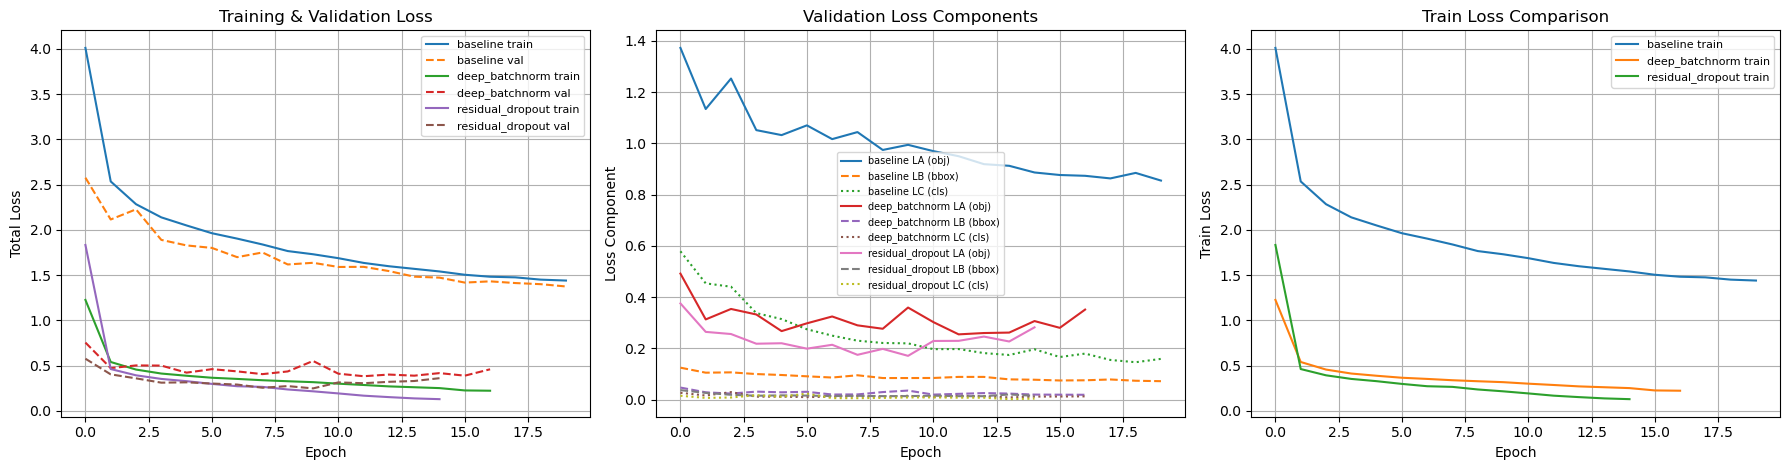


Under/overfitting check:
  baseline: final train_loss=1.4403, val_loss=1.3750, gap=-0.0653
  deep_batchnorm: final train_loss=0.2239, val_loss=0.4605, gap=0.2366
  residual_dropout: final train_loss=0.1307, val_loss=0.3624, gap=0.2316


In [ ]:
# Training curves (horizontal layout: 1 row x 3 columns).
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Figure 1: total train/validation loss.
ax = axes[0]
for name in model_names:
    h = histories[name]
    ax.plot(h["train_loss"], label=f"{name} train")
    ax.plot(h["val_loss"],   label=f"{name} val", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")
ax.set_title("Training & Validation Loss")
ax.grid(True)
ax.legend(fontsize=8)

# Figure 2: validation loss components.
ax = axes[1]
for name in model_names:
    h = histories[name]
    ax.plot(h["val_LA"], label=f"{name} LA (obj)")
    ax.plot(h["val_LB"], label=f"{name} LB (bbox)", linestyle="--")
    ax.plot(h["val_LC"], label=f"{name} LC (cls)", linestyle=":")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss Component")
ax.set_title("Validation Loss Components")
ax.grid(True)
ax.legend(fontsize=7)

# Figure 3: train loss comparison.
ax = axes[2]
for name in model_names:
    h = histories[name]
    ax.plot(h["train_loss"], label=f"{name} train")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Loss")
ax.set_title("Train Loss Comparison")
ax.grid(True)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Under/overfitting check.
print("\nUnder/overfitting check:")
for name in model_names:
    h = histories[name]
    print(f"  {name}: final train_loss={h['train_loss'][-1]:.4f}, val_loss={h['val_loss'][-1]:.4f}, "
          f"gap={h['val_loss'][-1] - h['train_loss'][-1]:.4f}")

In [ ]:
# Evaluate all models on validation & automatic selection.
results_rows = []
for name in model_names:
    print(f"\nEvaluating: {name}")
    model = trained_models[name]
    metrics = full_eval(model, val_loader, CONFIG, split_name=f"{name}/val")
    metrics["model"] = name
    results_rows.append(metrics)

results_df = pd.DataFrame(results_rows)
results_df = results_df[["model", "accuracy", "iou", "mean_metric", "mAP", "mAP_50"]]
print("\n" + "="*70)
print("Validation Results Summary:")
print("="*70)
print(results_df.to_string(index=False))

# Automatic model selection (argmax of mAP).
best_idx = results_df["mAP"].idxmax()
best_model_name = results_df.loc[best_idx, "model"]
print(f"\n*** Best model by validation mAP: {best_model_name} "
      f"(mAP={results_df.loc[best_idx, 'mAP']:.4f}, "
      f"mean_metric={results_df.loc[best_idx, 'mean_metric']:.4f}) ***")

best_model = trained_models[best_model_name]


Evaluating: baseline
  [baseline/val]  Accuracy=0.9400  IoU=0.4754  Mean=0.7077  mAP=0.1259  mAP@50=0.4349

Evaluating: deep_batchnorm
  [deep_batchnorm/val]  Accuracy=0.9828  IoU=0.6899  Mean=0.8363  mAP=0.4110  mAP@50=0.8461

Evaluating: residual_dropout
  [residual_dropout/val]  Accuracy=0.9898  IoU=0.7658  Mean=0.8778  mAP=0.5392  mAP@50=0.9226

Validation Results Summary:
           model  accuracy      iou  mean_metric      mAP   mAP_50
        baseline  0.939951 0.475384     0.707667 0.125894 0.434941
  deep_batchnorm  0.982811 0.689863     0.836337 0.410954 0.846137
residual_dropout  0.989776 0.765764     0.877770 0.539155 0.922626

*** Best model by validation mAP: residual_dropout (mAP=0.5392, mean_metric=0.8778) ***


## 3.1.2 Final Evaluation on Test Set

Evaluate only the automatically selected model on the test split to avoid test leakage and report final metrics.

In [ ]:
# Final test evaluation (ONCE, best model only). 
print(f"Final evaluation on TEST set using best model: {best_model_name}")
print(f"Threshold: pc >= {CONFIG['pc_threshold']}")
test_metrics = full_eval(best_model, test_loader, CONFIG, split_name=f"{best_model_name}/test")

# Also show train metrics for reference.
print(f"\nReference — train metrics:")
train_metrics = full_eval(best_model, train_loader, CONFIG, split_name=f"{best_model_name}/train")

print(f"\n{'='*60}")
print(f"FINAL TEST RESULTS ({best_model_name})")
print(f"{'='*60}")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Final evaluation on TEST set using best model: residual_dropout
Threshold: pc >= 0.5
  [residual_dropout/test]  Accuracy=0.9885  IoU=0.7683  Mean=0.8784  mAP=0.5423  mAP@50=0.9226

Reference — train metrics:
  [residual_dropout/train]  Accuracy=0.9965  IoU=0.7829  Mean=0.8897  mAP=0.5461  mAP@50=0.9272

FINAL TEST RESULTS (residual_dropout)
  accuracy: 0.9885
  iou: 0.7683
  mean_metric: 0.8784
  mAP: 0.5423
  mAP_50: 0.9226


## 3.1.2 Qualitative Results - Predicted vs Ground-Truth Boxes

Visualize train/validation examples with true and predicted bounding boxes to inspect localization and classification behavior.

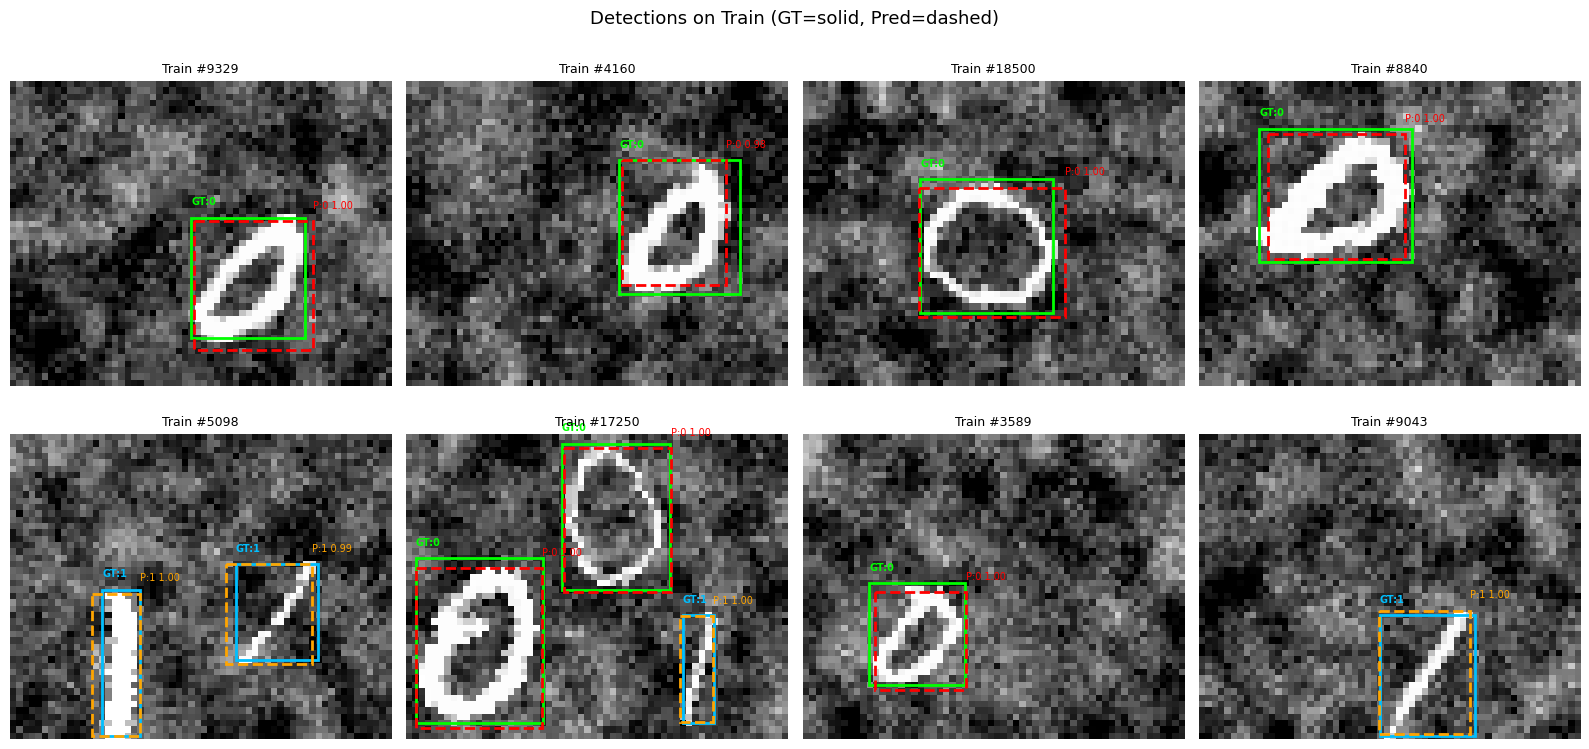

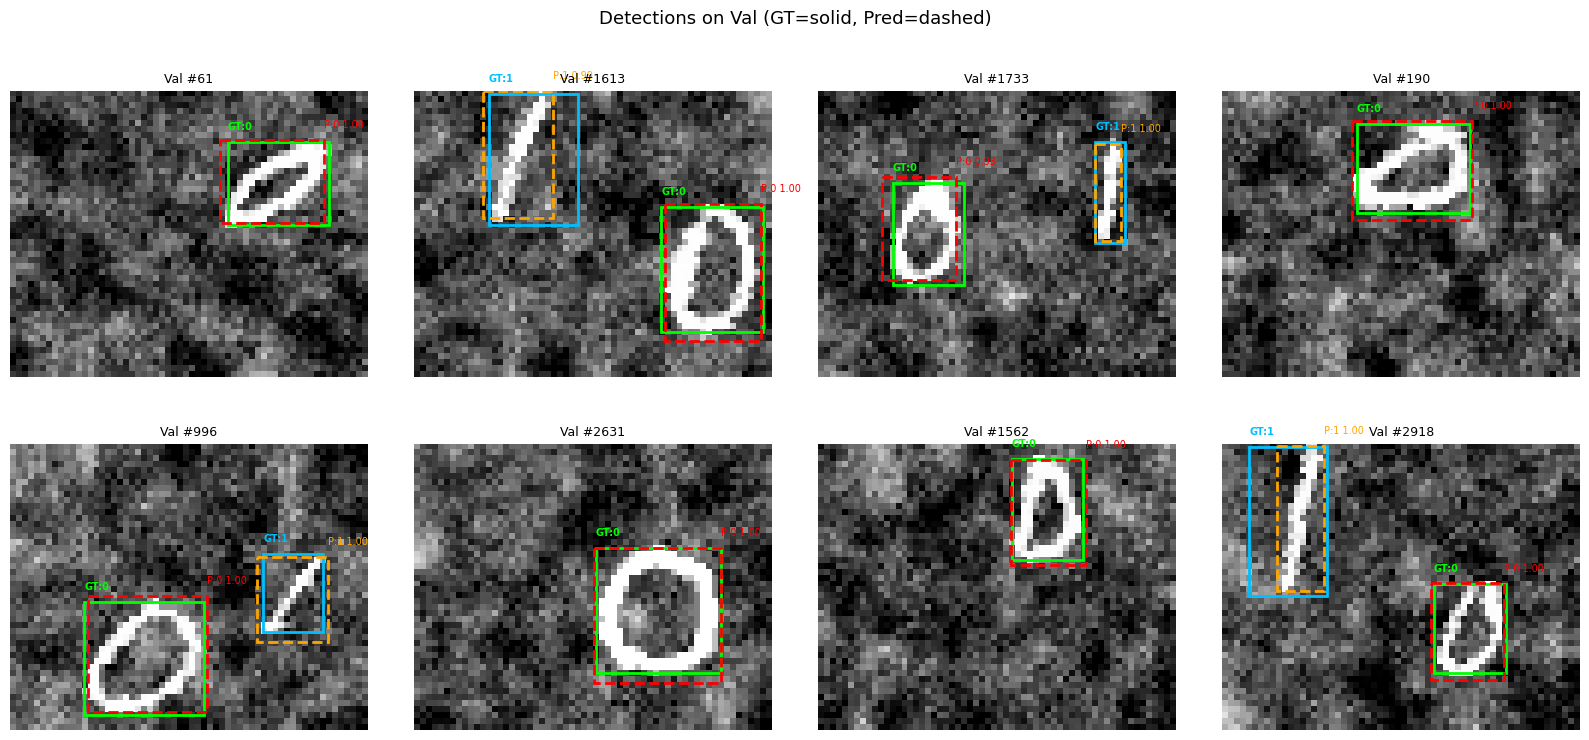

In [ ]:
def plot_detections(model, X, y_grid, list_y, indices, cfg, split_name="", unnorm_mean=None, unnorm_std=None):
    model.eval()
    n = len(indices)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flat

    gt_colors = {0: "lime", 1: "deepskyblue"}
    pred_colors = {0: "red", 1: "orange"}

    for ax_i, idx in enumerate(indices):
        ax = axes[ax_i]
        # Un-normalize for display
        img = X[idx, 0].cpu()
        if unnorm_mean is not None:
            img = img * unnorm_std + unnorm_mean
        img = img.clamp(0, 1).numpy()
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)

        # GT boxes from list labels
        for obj in list_y[idx]:
            pc, xc, yc, w, h, c = obj.tolist()
            if pc != 1:
                continue
            x1 = (xc - w/2) * cfg["Win"]
            y1 = (yc - h/2) * cfg["Hin"]
            rect = patches.Rectangle((x1, y1), w * cfg["Win"], h * cfg["Hin"],
                                     linewidth=2, edgecolor=gt_colors[int(c)],
                                     facecolor="none", linestyle="-")
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, f"GT:{int(c)}", color=gt_colors[int(c)], fontsize=7, weight="bold")

        # Predicted boxes
        with torch.no_grad():
            y_pred = model(X[idx:idx+1].to(device))
        preds = decode_predictions(
            y_pred, cfg["Hout"], cfg["Wout"], cfg["C"],
            pc_thresh=cfg["pc_threshold"]
        )
        pred = preds[0]
        for k in range(pred["boxes"].shape[0]):
            bx1, by1, bx2, by2 = pred["boxes"][k].tolist()
            lbl = pred["labels"][k].item()
            scr = pred["scores"][k].item()
            rect = patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                                     linewidth=2, edgecolor=pred_colors[lbl],
                                     facecolor="none", linestyle="--")
            ax.add_patch(rect)
            ax.text(bx2, by1 - 2, f"P:{lbl} {scr:.2f}", color=pred_colors[lbl], fontsize=7)

        ax.set_title(f"{split_name} #{idx}", fontsize=9)
        ax.axis("off")

    # Hide unused axes
    for j in range(ax_i + 1, len(list(axes))):
        axes[j].axis("off")

    fig.suptitle(f"Detections on {split_name} (GT=solid, Pred=dashed)", fontsize=13)
    plt.tight_layout()
    plt.show()


# Plot 8 train examples
rng_vis = np.random.RandomState(42)
train_vis_ids = rng_vis.choice(len(X_train), 8, replace=False).tolist()
plot_detections(best_model, X_train, y_train_grid, list_y_true_train,
                train_vis_ids, CONFIG, split_name="Train",
                unnorm_mean=train_mean.item(), unnorm_std=train_std.item())

#  Plot 8 val examples 
val_vis_ids = rng_vis.choice(len(X_val), 8, replace=False).tolist()
plot_detections(best_model, X_val, y_val_grid, list_y_true_val,
                val_vis_ids, CONFIG, split_name="Val",
                unnorm_mean=train_mean.item(), unnorm_std=train_std.item())

## 3.1.2 Error Analysis - Failure Cases

Identify and display representative false positives, false negatives, and low-IoU examples for qualitative failure analysis.

False Positive examples: [107, 153, 172, 186]


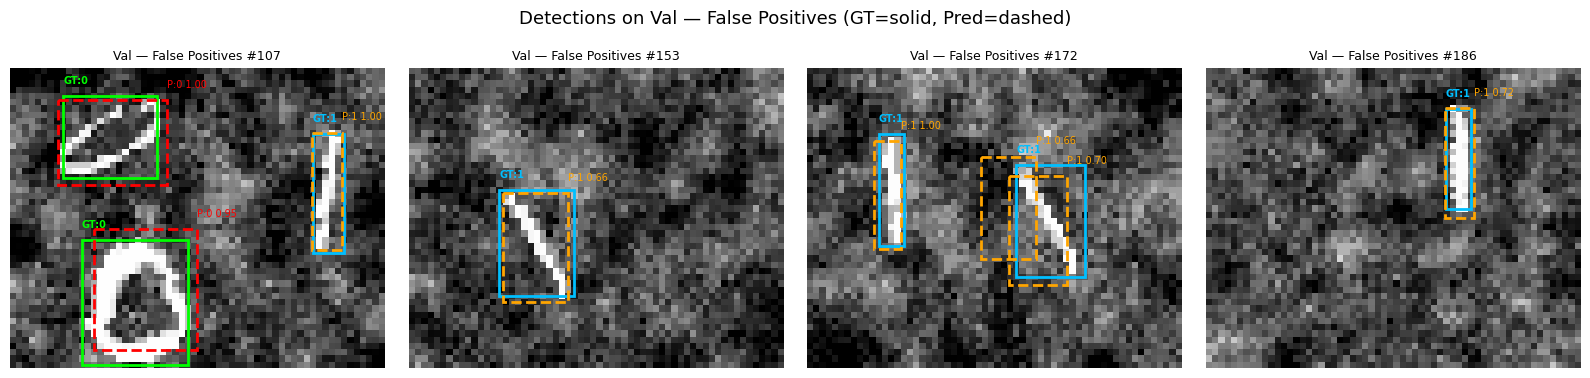

False Negative examples: [23, 107, 153, 186]


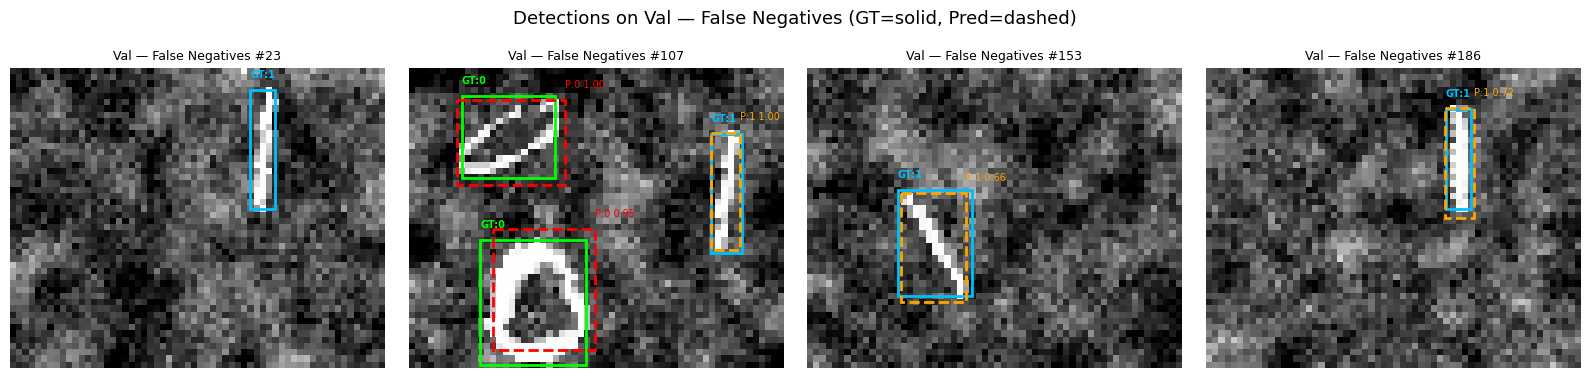

Low IoU examples: [19, 120, 205, 208]


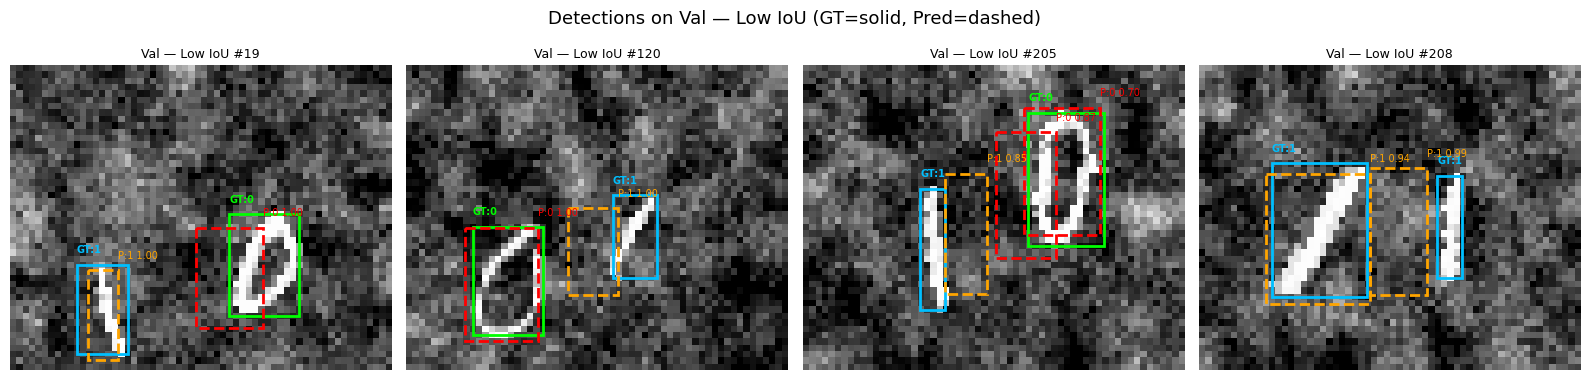

In [ ]:
# Failure analysis: find FP, FN, low-IoU examples. 
@torch.no_grad()
def find_failure_cases(model, X, y_grid, cfg, max_each=4):
    #Find indices of images with false positives, false negatives, or low IoU.
    model.eval()
    fp_ids, fn_ids, low_iou_ids = [], [], []
    thresh = cfg["pc_threshold"]
    
    # Process in batches for efficiency.
    for start in range(0, len(X), cfg["batch_size"]):
        end = min(start + cfg["batch_size"], len(X))
        X_b = X[start:end].to(device)
        y_pred = model(X_b)
        
        for k in range(X_b.shape[0]):
            idx = start + k
            pc_pred = (torch.sigmoid(y_pred[k, :, :, 0]) >= thresh).float()
            pc_true = y_grid[idx, :, :, 0].to(device)
            
            # False positives: predicted object but no GT.
            fp = ((pc_pred == 1) & (pc_true == 0)).any().item()
            # False negatives: GT object but not predicted.
            fn = ((pc_pred == 0) & (pc_true == 1)).any().item()
            
            if fp and len(fp_ids) < max_each:
                fp_ids.append(idx)
            if fn and len(fn_ids) < max_each:
                fn_ids.append(idx)
            
            # Low IoU: object cells where IoU < 0.3
            obj_cells = (pc_true == 1) & (pc_pred == 1)
            if obj_cells.any():
                for i in range(cfg["Hout"]):
                    for j in range(cfg["Wout"]):
                        if not obj_cells[i, j]:
                            continue
                        p = y_pred[k, i, j, 1:5]
                        t = y_grid[idx, i, j, 1:5]
                        px1, py1 = p[0]-p[2]/2, p[1]-p[3]/2
                        px2, py2 = p[0]+p[2]/2, p[1]+p[3]/2
                        tx1, ty1 = t[0]-t[2]/2, t[1]-t[3]/2
                        tx2, ty2 = t[0]+t[2]/2, t[1]+t[3]/2
                        ix1 = max(px1.item(), tx1.item())
                        iy1 = max(py1.item(), ty1.item())
                        ix2 = min(px2.item(), tx2.item())
                        iy2 = min(py2.item(), ty2.item())
                        inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                        union = p[2].item()*p[3].item() + t[2].item()*t[3].item() - inter
                        iou = inter / max(union, 1e-8)
                        if iou < 0.3 and len(low_iou_ids) < max_each:
                            low_iou_ids.append(idx)

            if len(fp_ids) >= max_each and len(fn_ids) >= max_each and len(low_iou_ids) >= max_each:
                break
    return fp_ids, fn_ids, low_iou_ids

fp_ids, fn_ids, low_iou_ids = find_failure_cases(best_model, X_val, y_val_grid, CONFIG, max_each=4)

if fp_ids:
    print(f"False Positive examples: {fp_ids}")
    plot_detections(best_model, X_val, y_val_grid, list_y_true_val, fp_ids, CONFIG,
                    split_name="Val — False Positives",
                    unnorm_mean=train_mean.item(), unnorm_std=train_std.item())

if fn_ids:
    print(f"False Negative examples: {fn_ids}")
    plot_detections(best_model, X_val, y_val_grid, list_y_true_val, fn_ids, CONFIG,
                    split_name="Val — False Negatives",
                    unnorm_mean=train_mean.item(), unnorm_std=train_std.item())

if low_iou_ids:
    print(f"Low IoU examples: {low_iou_ids}")
    plot_detections(best_model, X_val, y_val_grid, list_y_true_val, low_iou_ids, CONFIG,
                    split_name="Val — Low IoU",
                    unnorm_mean=train_mean.item(), unnorm_std=train_std.item())

if not fp_ids and not fn_ids and not low_iou_ids:
    print("No failure cases found in sample.")